Block 1 Checkpoint - Spring Pendulum

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
g = 9.81
m = 1.0
l_0 = 1.0
k = 100.0
t_0 = 0.0

def simulate_spring_pend(theta_0, dt, run_time):

    theta = np.deg2rad(theta_0)
    omega = 0.0
    t = t_0
    L = l_0
    disp = L - l_0
    v_disp = 0.0
    E_total = m*g*L*(1-np.cos(theta)) + 0.5*m*(omega**2)*(L**2) + 0.5*k*disp**2 + 0.5*m*v_disp**2

    state = {'t':[t], 'theta':[theta], 'omega':[omega], 'disp':[disp], 'v_disp':[v_disp], 'E':[E_total]}

    while t<=run_time:

        a_theta = - (g/L) * np.sin(theta) - 2*(v_disp/L)*omega
        a_disp = L * omega**2 + g * np.cos(theta) - (k/m) * disp 

        omega += a_theta * dt
        v_disp += a_disp * dt
        theta += omega * dt
        disp += v_disp * dt

        t += dt
        L = disp + l_0
        E_total = m*g*L*(1-np.cos(theta)) + 0.5*m*(omega**2)*(L**2) + 0.5*k*disp**2 + 0.5*m*v_disp**2

        state['t'].append(t)
        state['theta'].append(theta)
        state['omega'].append(omega)
        state['disp'].append(disp)
        state['v_disp'].append(v_disp)
        state['E'].append(E_total)

    return state

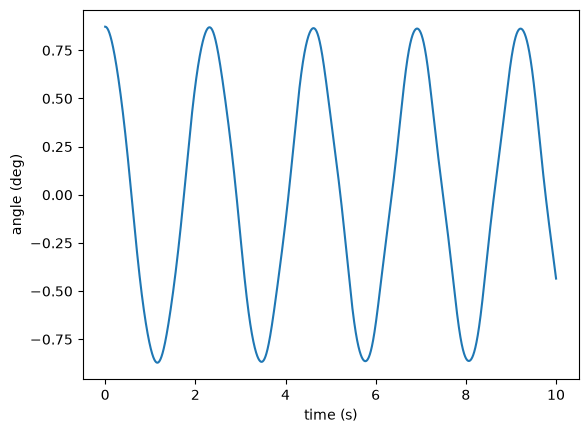

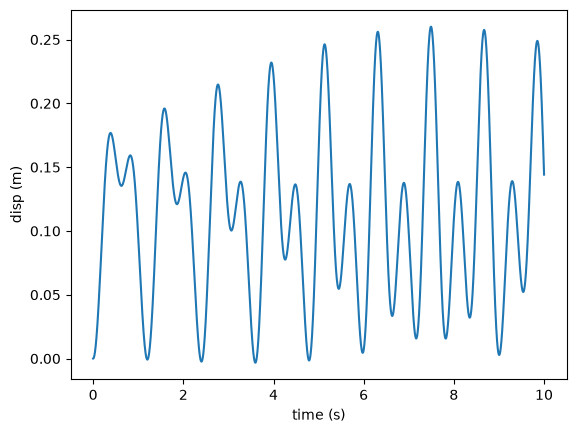

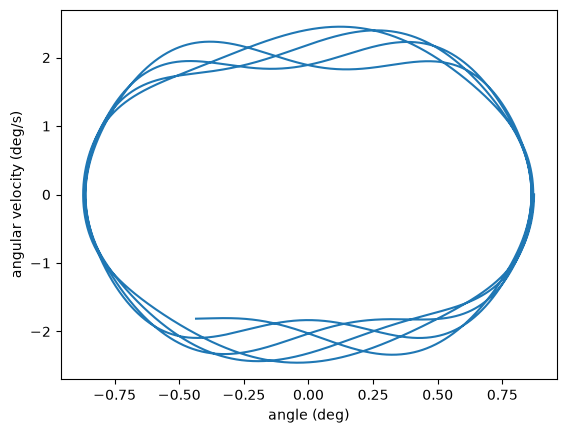

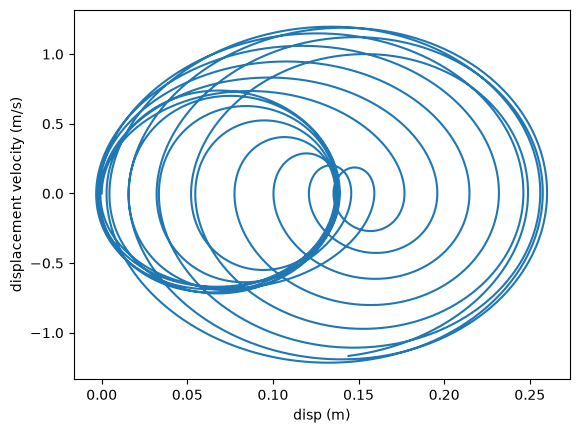

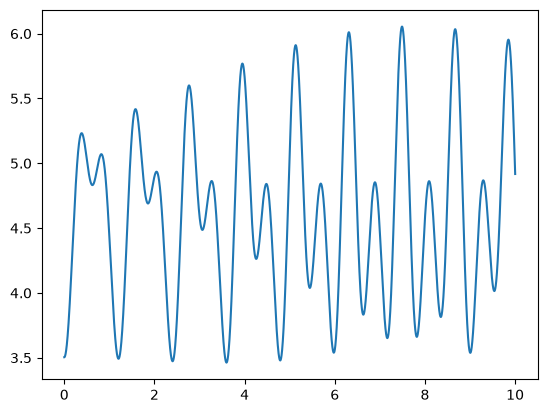

: 

In [ ]:
SP_Sim = simulate_spring_pend(50, 0.001, 10)

plt.plot(SP_Sim['t'], SP_Sim['theta'])
plt.xlabel('time (s)')
plt.ylabel('angle (deg)')
plt.show()
plt.plot(SP_Sim['t'], SP_Sim['disp'])
plt.xlabel('time (s)')
plt.ylabel('disp (m)')
plt.show()
plt.plot(SP_Sim['theta'], SP_Sim['omega'])
plt.xlabel('angle (deg)')
plt.ylabel('angular velocity (deg/s)')
plt.show()
plt.plot(SP_Sim['disp'], SP_Sim['v_disp'])
plt.xlabel('disp (m)')
plt.ylabel('displacement velocity (m/s)')
plt.show()
plt.plot(SP_Sim['t'], np.array(SP_Sim['E']))